In [1]:
import os
import json
import sys
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

project_root = os.path.abspath(os.path.join(os.getcwd(), "../../../.."))
sys.path.insert(0, project_root)

# Load modules 
from src.models.naive_cell import NaivePerCellModel
from src.utils.data_partition import temporal_split
from src.utils.transformations import ensure_full_grid
from src.evaluation.temporal_evaluation import (
                                                    evaluate_temporal_rmse_mae,
                                                    evaluate_temporal_spatial_metrics,
                                                    evaluate_spatial_metrics_over_coverages
                                                )

In [2]:
# Load global config 
config_path = os.path.join("../../", "config.json")
with open(config_path, 'r') as f:
    config = json.load(f)

# Define hotspot method from config
hotspot_percentage = config["evaluation"]["hotspot_percentage"]
hotspot_method = config["evaluation"].get("hotspot_definition", "by_cells")  # default

# Dynamically select hotspot definition method
if hotspot_method == "by_crimes":
    from src.utils.spatial_processing import define_hotspot_by_crimes as define_hotspot
elif hotspot_method == "by_cells":
    from src.utils.spatial_processing import define_hotspot_by_cells as define_hotspot
else:
    raise ValueError(f"Unknown hotspot_definition method: {hotspot_method}") 

# Partition data
partition_config = config["data_partition"]
days_per_month = 30
train_days = partition_config["train_months"] * days_per_month
calibration_days = partition_config["calibration_months"] * days_per_month
test_days = partition_config["test_months"] * days_per_month

# Paths
data_dir = "../../data/real_data/Chicago/"
df_path = os.path.join(data_dir, "chicago_crime_processed.csv")
map_path = os.path.join(data_dir, "beat_to_coord_map.json")

# Load
df = pd.read_csv(df_path)
with open(map_path) as f:
    beat_to_coord_map = json.load(f)

crime_types=df["crime_type"].unique()


df=df[df["crime_type"].isin(crime_types)].groupby(["timestep","row","col"]).sum().drop("crime_type",axis=1).reset_index()
df=ensure_full_grid(df, df.timestep.max(), tuple(df[["row","col"]].max()+1))
df.to_csv(os.path.join(data_dir,"df_used.csv"),index=False)
rows, cols = tuple(df[["row","col"]].max()+1)
grid_size = (rows, cols)
# Check structure
df.head()

,timestep,row,col,count
0,0,0,0,5
1,0,0,1,3
2,0,0,2,0
3,0,0,3,3
4,0,0,4,1


In [3]:
def simulate_iid_poisson_from_empirical(df, n_timesteps=None, seed=7):
    """
    df: columns ['timestep','row','col','count'] con datos reales.
    Retorna un DataFrame con simulaciones Poisson i.i.d. por celda,
    usando la media empírica por celda como lambda.
    """
    rng = np.random.default_rng(seed)
    # λ por celda = media empírica
    lam = (df.groupby(['row','col'])['count']
             .mean()
             .rename('lam')
             .reset_index())

    # nT de salida
    T_real = int(df['timestep'].max() + 1)
    T = T_real if n_timesteps is None else int(n_timesteps)

    out = []
    
    for _, r in lam.iterrows():
        y = rng.poisson(r['lam'], size=T)
        out.append(pd.DataFrame({
            'timestep': np.arange(T, dtype=int),
            'row': int(r['row']),
            'col': int(r['col']),
            'count': y
        }))
    return pd.concat(out, ignore_index=True)


In [4]:
df = simulate_iid_poisson_from_empirical (df,seed=10)
output_df_path = Path("../../data/dummy_data/chicago_dummy.csv")
os.makedirs(output_df_path.parent, exist_ok=True)
df.to_csv(output_df_path, index=False)
df

,timestep,row,col,count
0,0,0,0,3
1,1,0,0,4
2,2,0,0,7
3,3,0,0,3
4,4,0,0,5
...,...,...,...,...
105480,360,16,16,0
105481,361,16,16,0
105482,362,16,16,0
105483,363,16,16,0


In [5]:
df_train, df_calib, df_test = temporal_split(df, train_days, train_days + calibration_days, train_days + calibration_days + test_days)

# Features
features = ["timestep", "row", "col"]
target = "count"

X_train, y_train = df_train[features], df_train[target]
X_test, y_test = df_test[features], df_test[target]

# Train cell-based models
naive_model = NaivePerCellModel()
naive_model.fit(X_train, y_train)


# Save models
path_dir="../../results/models/dummy_data/Chicago/"
os.makedirs(path_dir, exist_ok=True)
joblib.dump(naive_model, os.path.join(path_dir,"naive_cell_model.pkl"))

# Predict
naive_pred = naive_model.predict(X_test)

# Temporal numeric evaluation
print("\n🔹 Temporal numeric evaluation (per timestep):\n")
for name, pred in zip(["NaiveCell", "PoissonPerCell"], [naive_pred]):
    scores = evaluate_temporal_rmse_mae(X_test, y_test, pred)
    print(f"{name} - RMSE: {scores['rmse_mean']:.3f} ± {scores['rmse_std']:.3f} | MAE: {scores['mae_mean']:.3f} ± {scores['mae_std']:.3f}")

# Temporal spatial evaluation
print("\n🔹 Temporal spatial metrics (per timestep):\n")
for name, pred in zip(["NaiveCell", "PoissonPerCell"], [naive_pred]):
    spatial_scores = evaluate_temporal_spatial_metrics(X_test, y_test, pred, grid_size, hotspot_percentage)
    print(f"{name}:")
    print(f"  PAI:     {spatial_scores['pai_mean']:.3f} ± {spatial_scores['pai_std']:.3f}")
    print(f"  PEI:     {spatial_scores['pei_mean']:.3f} ± {spatial_scores['pei_std']:.3f}")
    print(f"  PEI*:    {spatial_scores['pei_star_mean']:.3f} ± {spatial_scores['pei_star_std']:.3f}\n")

# 🔄 Evaluate over multiple coverages
coverages = np.linspace(0.01, 0.5, 10)
curves = {}
for name, pred in zip(["NaiveCell", "PoissonPerCell"], [naive_pred]):
    curves[name] = evaluate_spatial_metrics_over_coverages(X_test, y_test, pred, grid_size, coverages)


🔹 Temporal numeric evaluation (per timestep):

NaiveCell - RMSE: 1.287 ± 0.060 | MAE: 0.983 ± 0.042

🔹 Temporal spatial metrics (per timestep):

NaiveCell:
  PAI:     1.663 ± 0.115
  PEI:     0.591 ± 0.043
  PEI*:    0.676 ± 0.045



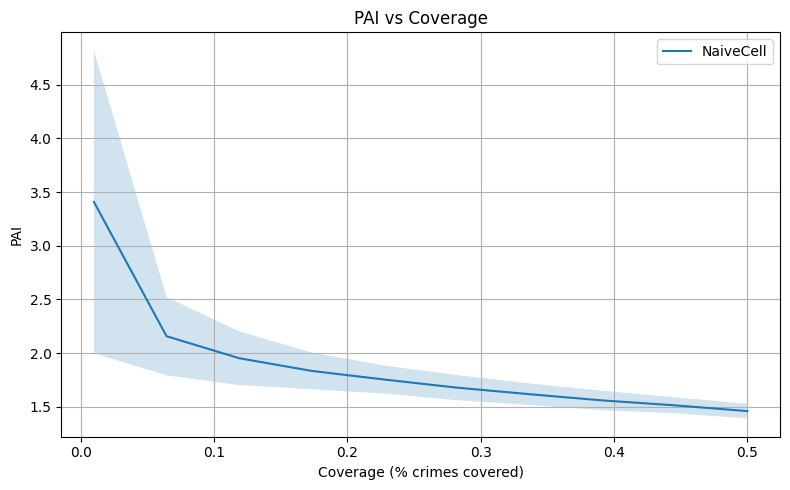

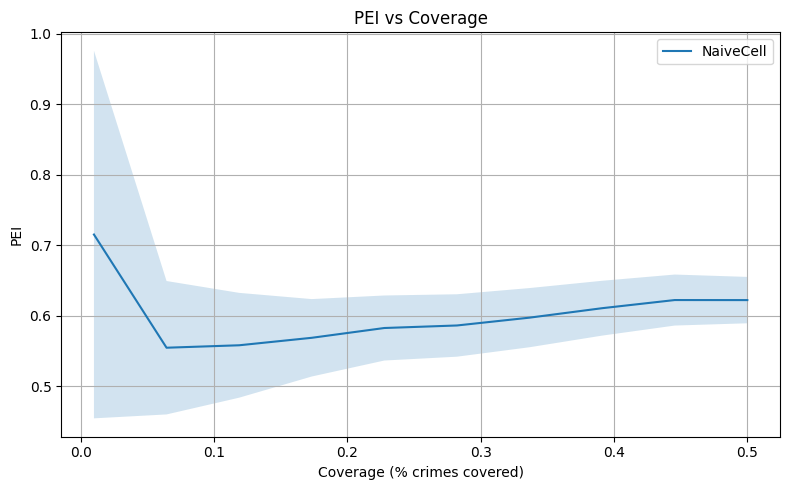

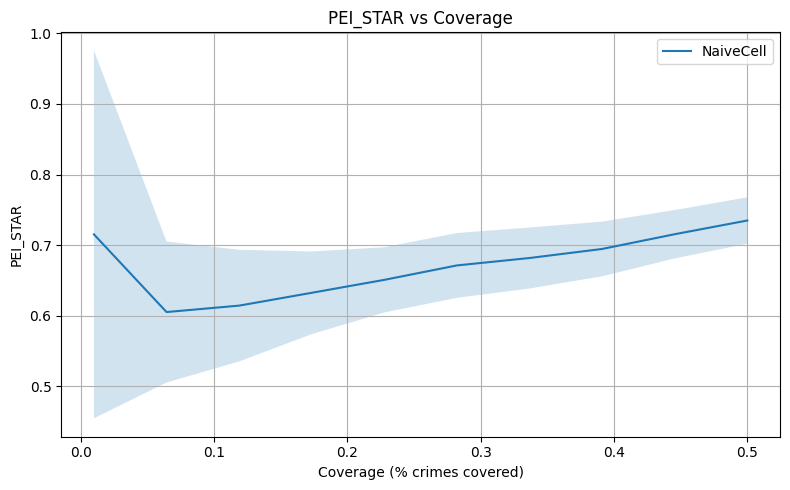

In [6]:
# 📈 Plot curves with seaborn
metrics = ["pai", "pei", "pei_star"]
for metric in metrics:
    plt.figure(figsize=(8, 5))
    for model in curves:
        df = curves[model]
        mean_col = f"{metric}_mean"
        std_col = f"{metric}_std"
        
        sns.lineplot(x="coverage", y=mean_col, data=df, label=model)
        plt.fill_between(df["coverage"], df[mean_col] - df[std_col], df[mean_col] + df[std_col], alpha=0.2)

    plt.xlabel("Coverage (% crimes covered)")
    plt.ylabel(metric.upper())
    plt.title(f"{metric.upper()} vs Coverage")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()